# CH 6 - Factor 5 - Variation in Expected Returns among the ATRs

## Objectif pédagogique

Ce notebook transforme le **Factor 5** de David Aronson en intuition quantitative et en simulation Python.

Le thème central est simple : le **biais de minage de données** dépend fortement de la **variation du mérite réel** entre les règles testées.

> Quand toutes les règles ont le même mérite réel, le gagnant du backtest est surtout choisi par le hasard. Quand une règle possède un vrai avantage supérieur, sa victoire devient plus crédible.

Dans ce notebook, on va simuler deux univers :

| Univers testé | Mérite réel des règles | Source probable de la victoire |
|---|---:|---|
| **Mérite égal** | Toutes les règles ont la même espérance | Hasard + sélection |
| **Mérite variable** | Une ou plusieurs règles ont un vrai avantage | Mérite réel + un peu de hasard |

L'objectif n'est pas de prouver qu'une stratégie est rentable, mais de comprendre pourquoi certains backtests gagnants sont plus suspects que d'autres.


## 1. Le concept EBTA

Dans un processus de **data mining**, on teste souvent beaucoup de règles de trading, puis on sélectionne celle qui affiche la meilleure performance historique.

Le problème est que la meilleure performance observée peut être décomposée ainsi :

$$
P_{obs} = P_{real} + H
$$

où :

- $P_{obs}$ est la performance observée en backtest.
- $P_{real}$ est le mérite réel ou pouvoir prédictif de la règle.
- $H$ est la composante de hasard.

Le **biais de minage** peut être vu comme l'écart entre la performance observée du gagnant et son mérite réel :

$$
Biais = P_{obs, gagnant} - P_{real, gagnant}
$$

> Plus les règles ont un mérite réel similaire, plus la victoire du gagnant dépend du hasard. Plus les mérites réels sont dispersés, plus le gagnant peut être sélectionné pour une vraie raison.


## 2. Intuition trading

Imagine que tu testes 1 000 variantes d'une stratégie :

- EMA 10/20
- EMA 11/20
- EMA 12/20
- EMA 13/20
- etc.

Si toutes ces variantes sont presque identiques, leur **mérite réel** est presque identique. Dans ce cas, celle qui gagne le backtest n'est pas forcément meilleure : elle a simplement eu la meilleure coïncidence avec l'échantillon historique.

À l'inverse, si ton univers contient des logiques très différentes — **momentum**, **mean reversion**, **volatility breakout**, **carry**, **trend following** — alors il existe potentiellement une vraie dispersion de mérite.

Cette dispersion augmente la chance que le gagnant soit sélectionné pour son **edge réel**, pas uniquement pour son bruit favorable.


## 3. Simulation Python

Nous allons simuler des règles artificielles de trading, appelées ici **ATR** pour *Artificial Trading Rules*.

Chaque règle possède :

- un **mérite réel** : son rendement moyen attendu ;
- une **performance observée** : son mérite réel plus du bruit d'échantillonnage.

La logique de simulation est :

$$
\hat{\mu}_i = \mu_i + \epsilon_i
$$

avec :

$$
\epsilon_i \sim \mathcal{N}\left(0, \frac{\sigma}{\sqrt{n}}\right)
$$

où :

- $\hat{\mu}_i$ est la performance observée de la règle $i$.
- $\mu_i$ est le mérite réel de la règle $i$.
- $\sigma$ est la volatilité des rendements.
- $n$ est le nombre d'observations utilisées pour calculer la performance.

Plus $n$ est petit, plus le bruit est grand.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Paramètres généraux
n_rules = 1000          # Nombre de règles testées
n_obs = 120             # Nombre d'observations par règle, ex: 120 mois = 10 ans
sigma = 0.10            # Volatilité annualisée simplifiée du bruit
n_experiments = 5000    # Nombre de compétitions simulées

noise_std = sigma / np.sqrt(n_obs)
noise_std


np.float64(0.009128709291752768)

## 4. Fonction de simulation d'une compétition de backtest

Une compétition de backtest suit trois étapes :

1. Générer le mérite réel de chaque règle.
2. Ajouter du bruit d'échantillonnage à chaque règle.
3. Sélectionner la règle avec la meilleure performance observée.

Ensuite, on mesure le **biais de minage** du gagnant.


In [2]:
def simulate_backtest_competition(true_merits, noise_std, rng):
    """Simule une compétition de backtest entre plusieurs règles."""
    noise = rng.normal(loc=0.0, scale=noise_std, size=len(true_merits))
    observed_perf = true_merits + noise
    winner_idx = np.argmax(observed_perf)

    return {
        "winner_idx": winner_idx,
        "winner_true_merit": true_merits[winner_idx],
        "winner_observed_perf": observed_perf[winner_idx],
        "data_mining_bias": observed_perf[winner_idx] - true_merits[winner_idx],
        "winner_rank_by_true_merit": int(np.sum(true_merits > true_merits[winner_idx]) + 1),
    }


## 5. Scénario A — Univers à mérite égal

Dans ce scénario, toutes les règles ont un mérite réel de $0\%$.

$$
\mu_1 = \mu_2 = \mu_3 = \dots = \mu_{1000} = 0
$$

Donc, si une règle gagne le backtest, elle ne peut pas gagner grâce à son talent. Elle gagne uniquement grâce au bruit.

> C'est l'univers le plus dangereux : le backtest crée l'illusion d'un champion là où il n'existe aucun edge.


In [3]:
equal_merits = np.zeros(n_rules)

results_equal = [
    simulate_backtest_competition(equal_merits, noise_std, rng)
    for _ in range(n_experiments)
]

df_equal = pd.DataFrame(results_equal)
df_equal.describe(percentiles=[0.05, 0.5, 0.95])


,winner_idx,winner_true_merit,winner_observed_perf,data_mining_bias,winner_rank_by_true_merit
count,5000.000000,5000.0,5000.000000,5000.000000,5000.0
mean,498.052000,0.0,0.029608,0.029608,1.0
std,286.761679,0.0,0.003262,0.003262,0.0
min,0.000000,0.0,0.021692,0.021692,1.0
5%,52.000000,0.0,0.025181,0.025181,1.0
50%,490.500000,0.0,0.029155,0.029155,1.0
95%,948.000000,0.0,0.035590,0.035590,1.0
max,999.000000,0.0,0.048490,0.048490,1.0


## 6. Scénario B — Univers avec une règle réellement supérieure

Dans ce scénario :

- 999 règles ont un mérite réel de $0\%$.
- 1 règle a un mérite réel de $5\%$.

$$
\mu_{champion} = 5\%
$$

Cette règle possède un vrai avantage. Elle peut encore perdre certaines compétitions à cause du hasard, mais elle a une probabilité plus élevée de gagner.


In [4]:
variable_merits = np.zeros(n_rules)
variable_merits[0] = 0.05  # Une règle réellement supérieure avec +5% de mérite réel

results_variable = [
    simulate_backtest_competition(variable_merits, noise_std, rng)
    for _ in range(n_experiments)
]

df_variable = pd.DataFrame(results_variable)
df_variable.describe(percentiles=[0.05, 0.5, 0.95])


,winner_idx,winner_true_merit,winner_observed_perf,data_mining_bias,winner_rank_by_true_merit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,9.431200,0.049060,0.050160,0.001100,1.018800
std,79.742447,0.006792,0.008959,0.009714,0.135832
min,0.000000,0.000000,0.026490,-0.023345,1.000000
5%,0.000000,0.050000,0.035200,-0.013799,1.000000
50%,0.000000,0.050000,0.050105,0.000552,1.000000
95%,0.000000,0.050000,0.065265,0.017295,1.000000
max,994.000000,0.050000,0.080253,0.044272,2.000000


## 7. Comparaison des deux univers

Nous comparons maintenant :

- la performance observée du gagnant ;
- le mérite réel du gagnant ;
- le biais de minage ;
- la fréquence à laquelle la vraie meilleure règle est sélectionnée.


In [5]:
summary = pd.DataFrame({
    "Univers": ["Mérite égal", "Mérite variable"],
    "Performance observée moyenne du gagnant": [
        df_equal["winner_observed_perf"].mean(),
        df_variable["winner_observed_perf"].mean(),
    ],
    "Mérite réel moyen du gagnant": [
        df_equal["winner_true_merit"].mean(),
        df_variable["winner_true_merit"].mean(),
    ],
    "Biais moyen": [
        df_equal["data_mining_bias"].mean(),
        df_variable["data_mining_bias"].mean(),
    ],
    "Probabilité de sélectionner la vraie meilleure règle": [
        np.nan,
        (df_variable["winner_idx"] == 0).mean(),
    ],
})

summary.style.format({
    "Performance observée moyenne du gagnant": "{:.2%}",
    "Mérite réel moyen du gagnant": "{:.2%}",
    "Biais moyen": "{:.2%}",
    "Probabilité de sélectionner la vraie meilleure règle": "{:.2%}",
})


,Univers,Performance observée moyenne du gagnant,Mérite réel moyen du gagnant,Biais moyen,Probabilité de sélectionner la vraie meilleure règle
0,Mérite égal,2.96%,0.00%,2.96%,nan%
1,Mérite variable,5.02%,4.91%,0.11%,98.12%


## 8. Visualisation du biais de minage

Le graphique suivant montre la distribution du **biais de minage** dans les deux scénarios.

Dans l'univers à mérite égal, le biais du gagnant est presque toute sa performance.

Dans l'univers à mérite variable, une partie de la performance du gagnant vient du mérite réel, donc la part de hasard peut diminuer.


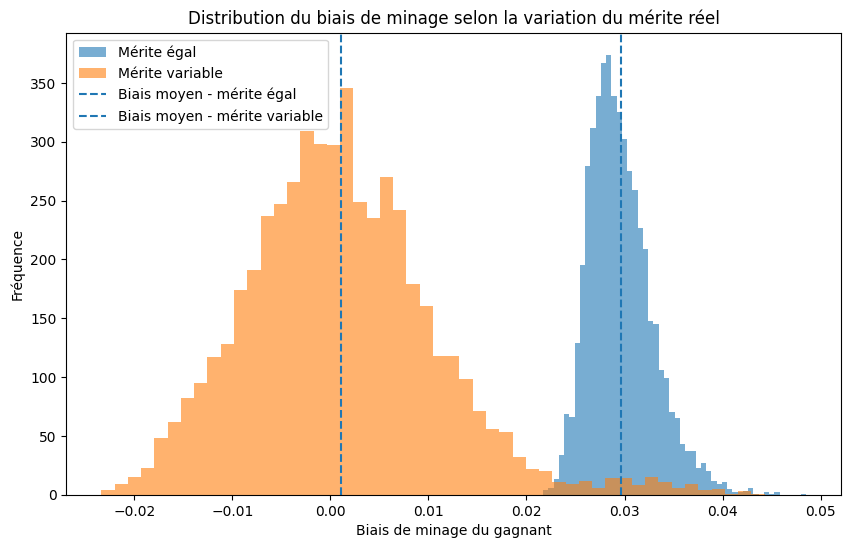

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df_equal["data_mining_bias"], bins=50, alpha=0.6, label="Mérite égal")
plt.hist(df_variable["data_mining_bias"], bins=50, alpha=0.6, label="Mérite variable")
plt.axvline(df_equal["data_mining_bias"].mean(), linestyle="--", label="Biais moyen - mérite égal")
plt.axvline(df_variable["data_mining_bias"].mean(), linestyle="--", label="Biais moyen - mérite variable")
plt.title("Distribution du biais de minage selon la variation du mérite réel")
plt.xlabel("Biais de minage du gagnant")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 9. Expérience : augmenter progressivement la dispersion du mérite réel

On va maintenant créer plusieurs univers où les règles ont un mérite réel plus ou moins dispersé.

L'idée est de simuler :

$$
\mu_i \sim \mathcal{N}(0, \tau)
$$

avec $\tau$ qui représente la **dispersion du mérite réel**.

- Si $\tau = 0$, toutes les règles ont le même mérite.
- Si $\tau$ augmente, certaines règles sont réellement meilleures que d'autres.

> Plus la dispersion du mérite réel augmente, plus le gagnant du backtest a de chances d'être choisi pour une vraie raison.


In [7]:
def run_merit_dispersion_experiment(dispersions, n_rules, noise_std, n_experiments, rng):
    rows = []

    for tau in dispersions:
        biases = []
        winner_true_merits = []
        observed_winners = []
        true_best_selected = []

        for _ in range(n_experiments):
            true_merits = rng.normal(loc=0.0, scale=tau, size=n_rules)
            true_best_idx = np.argmax(true_merits)
            result = simulate_backtest_competition(true_merits, noise_std, rng)

            biases.append(result["data_mining_bias"])
            winner_true_merits.append(result["winner_true_merit"])
            observed_winners.append(result["winner_observed_perf"])
            true_best_selected.append(result["winner_idx"] == true_best_idx)

        rows.append({
            "dispersion_merite_reel": tau,
            "biais_moyen": np.mean(biases),
            "merite_reel_moyen_du_gagnant": np.mean(winner_true_merits),
            "performance_observee_moyenne_du_gagnant": np.mean(observed_winners),
            "proba_selection_vrai_meilleur": np.mean(true_best_selected),
        })

    return pd.DataFrame(rows)

# On garde moins d'expériences ici pour que le notebook reste rapide à exécuter.
dispersions = np.linspace(0.0, 0.05, 11)
df_dispersion = run_merit_dispersion_experiment(
    dispersions=dispersions,
    n_rules=n_rules,
    noise_std=noise_std,
    n_experiments=1000,
    rng=rng,
)

df_dispersion.style.format({
    "dispersion_merite_reel": "{:.2%}",
    "biais_moyen": "{:.2%}",
    "merite_reel_moyen_du_gagnant": "{:.2%}",
    "performance_observee_moyenne_du_gagnant": "{:.2%}",
    "proba_selection_vrai_meilleur": "{:.2%}",
})


,dispersion_merite_reel,biais_moyen,merite_reel_moyen_du_gagnant,performance_observee_moyenne_du_gagnant,proba_selection_vrai_meilleur
0,0.00%,2.95%,0.00%,2.95%,0.00%
1,0.50%,2.60%,0.77%,3.37%,4.10%
2,1.00%,2.02%,2.38%,4.40%,15.90%
3,1.50%,1.53%,4.18%,5.71%,28.60%
4,2.00%,1.27%,5.83%,7.10%,37.10%
5,2.50%,0.95%,7.65%,8.61%,49.50%
6,3.00%,0.93%,9.32%,10.25%,54.30%
7,3.50%,0.76%,10.95%,11.71%,59.30%
8,4.00%,0.63%,12.72%,13.35%,64.40%
9,4.50%,0.54%,14.37%,14.91%,68.30%


## 10. Graphique : dispersion du mérite réel et biais

Ce graphique illustre l'idée centrale du facteur 5.

Quand la dispersion du mérite réel augmente, le biais moyen tend à diminuer, car le gagnant dépend moins exclusivement du hasard.


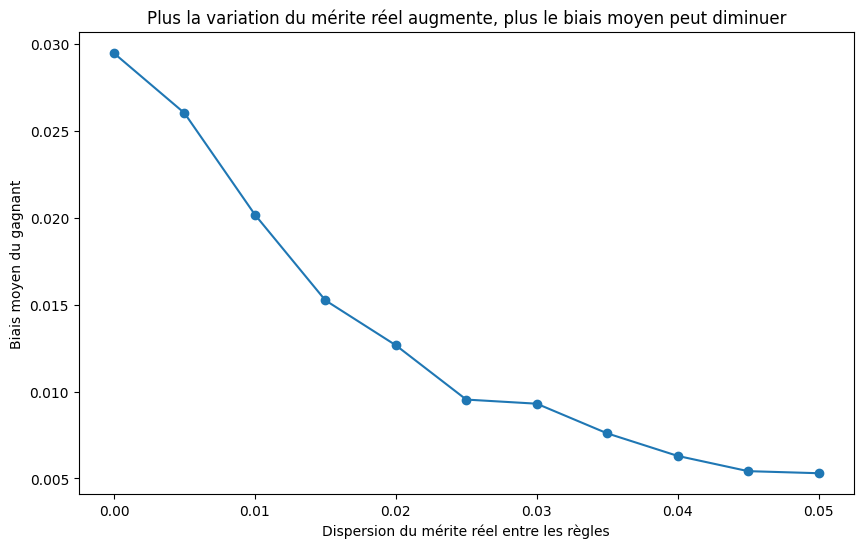

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(df_dispersion["dispersion_merite_reel"], df_dispersion["biais_moyen"], marker="o")
plt.title("Plus la variation du mérite réel augmente, plus le biais moyen peut diminuer")
plt.xlabel("Dispersion du mérite réel entre les règles")
plt.ylabel("Biais moyen du gagnant")
plt.show()


## 11. Graphique : probabilité de sélectionner la vraie meilleure règle

Ce deuxième graphique montre la probabilité que la règle choisie par le backtest soit réellement la meilleure règle de l'univers testé.

Quand toutes les règles se valent presque, le backtest a du mal à identifier un vrai champion.

Quand les mérites réels se différencient fortement, la sélection devient plus fiable.


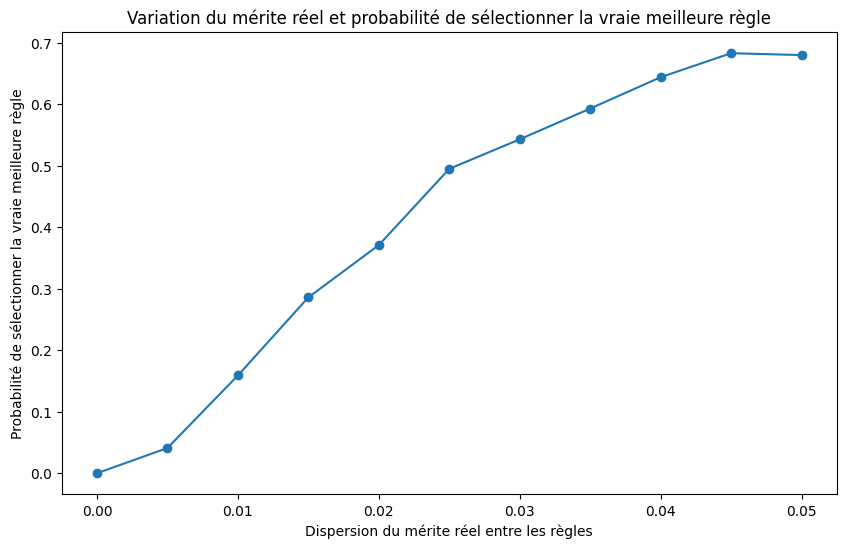

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(df_dispersion["dispersion_merite_reel"], df_dispersion["proba_selection_vrai_meilleur"], marker="o")
plt.title("Variation du mérite réel et probabilité de sélectionner la vraie meilleure règle")
plt.xlabel("Dispersion du mérite réel entre les règles")
plt.ylabel("Probabilité de sélectionner la vraie meilleure règle")
plt.show()


## 12. Lecture EBTA pour un trader algorithmique

Le message opérationnel est très important.

Tester plus de règles n'est pas forcément mauvais. Ce qui est dangereux, c'est de tester beaucoup de règles qui ont toutes le même faible mérite réel.

| Situation | Risque de biais | Interprétation |
|---|---:|---|
| 1 000 variantes proches d'une même idée faible | Très élevé | Le gagnant est probablement une coïncidence |
| 1 000 règles issues de logiques variées et justifiées | Plus faible | Le gagnant peut refléter un vrai edge |
| Une règle théoriquement solide et nettement supérieure | Plus faible | La performance observée est plus crédible |

> Le minage de données n'est pas seulement une question de quantité de règles testées. C'est aussi une question de qualité et de diversité du mérite réel dans l'univers de recherche.


## 13. Application pratique à ton pipeline de backtest

Pour ton processus EBTA, ce facteur donne quatre règles concrètes.

### Règle 1 — Ne pas optimiser une idée faible

Avant d'optimiser les paramètres, demande-toi :

> Est-ce que cette famille de règles a une raison économique, comportementale ou microstructurelle d'exister ?

Sans hypothèse de départ, l'optimisation devient une machine à fabriquer des illusions.

### Règle 2 — Séparer les familles de stratégies

Ne mélange pas toutes les variantes dans une seule compétition aveugle.

Crée plutôt des familles :

| Famille | Exemple de logique |
|---|---|
| **Momentum** | Acheter la continuation après impulsion |
| **Mean reversion** | Acheter l'excès baissier court terme |
| **Volatility breakout** | Trader l'expansion de range |
| **Liquidity sweep** | Trader après prise de liquidité |
| **VWAP / value** | Trader les retours vers une zone de valeur |

Cela permet de savoir si le gagnant vient d'une logique robuste ou d'un simple paramètre chanceux.

### Règle 3 — Regarder l'écart entre le gagnant et les autres

Si le gagnant bat le deuxième de très peu, prudence.

Cela signifie souvent que plusieurs règles ont un mérite observé très proche, donc que la sélection peut être instable.

### Règle 4 — Tester la stabilité hors échantillon

Un vrai mérite doit survivre à :

- un **walk-forward test** ;
- un **out-of-sample test** ;
- un **bootstrap** ;
- une **permutation de Monte Carlo** ;
- une analyse de sensibilité des paramètres.


## 14. Eurêka final

> Le biais de minage est maximal quand le backtest organise une compétition entre des règles sans différence réelle de talent.

> Le biais diminue quand l'univers de recherche contient une règle réellement supérieure, car la victoire du gagnant repose davantage sur son mérite que sur une coïncidence favorable.

En une phrase :

> **Plus les règles testées se ressemblent en mérite réel, plus le backtest choisit le hasard. Plus une règle se détache réellement, plus le backtest peut choisir le talent.**


## 15. Mini-exercice

Modifie les paramètres suivants dans le notebook :

```python
n_rules = 1000
n_obs = 120
sigma = 0.10
```

Puis observe :

- Que se passe-t-il si tu passes de 1 000 à 10 000 règles ?
- Que se passe-t-il si tu passes de 120 observations à 600 observations ?
- Que se passe-t-il si la règle supérieure passe de $5\%$ à $1\%$ de mérite réel ?

Conclusion attendue :

> Plus tu testes de règles similaires avec peu de données, plus tu amplifies la sélection du hasard. Plus tu as de données et une vraie différence de mérite, plus la sélection devient fiable.


## Annexe — Source originale collée

Le texte ci-dessous est la source fournie pour générer ce notebook.


### **CH 6 : FACTOR 5 - VARIATION IN EXPECTED RETURNS AMONG THE ATRs**

Voici l’analyse technique du cinquième et dernier facteur influençant l’ampleur du biais de minage de données : la variation du mérite réel (rendement attendu) au sein de l’univers des règles testées.

#### **Idées clés :**
*   **L'impact de la diversité de talent :** Le biais de minage est inversement proportionnel à la variation du mérite réel parmi les règles testées.
*   **Le piège de l'égalité :** Si toutes les règles testées ont un mérite identique (qu'il soit nul, faible ou élevé), toute différence de performance en backtest est due à 100 % au hasard.
*   **La règle supérieure comme anccre :** La présence d'une règle réellement dominante dans l'échantillon réduit mécaniquement le biais car sa victoire repose sur son talent et non sur une coïncidence chanceuse.
*   **L'effet "Illumination" :** Un mérite élevé permet à la performance réelle de "percer le brouillard" du hasard, rendant l'estimation du backtest plus proche de la vérité.

#### **Référence :**
*Factor 5: Variation in Expected Returns among the ATRs*, Chapitre 6, pages 306 à 307.

#### **Citation Directe :**
« When all rules are of equal merit, be that merit none, low, or high, any differences in their observed performances are due entirely to luck. [...] In such a case... the data-mining bias will be large. » (Page 307).

---

#### **Vision Macro :**
L'enjeu est la source de la victoire. David Aronson explique que le biais de minage est une mesure du "mensonge" statistique. Si vous organisez une compétition entre des candidats qui ont tous le même niveau, le gagnant sera désigné uniquement par la chance ; son score sera donc un mensonge total sur ses capacités réelles. En revanche, si l'un des candidats est un "génie" (une règle avec un fort pouvoir prédictif), sa victoire est légitime. Dans ce cas, le profit affiché par le backtest est une mesure beaucoup plus honnête du futur, car la part de chance nécessaire pour gagner était bien plus faible.

---

#### **Vision Micro :**

1.  **Univers à faible variance (Mérite Égal) :**
    *   **Scénario :** Vous testez 1 000 règles dont l'espérance de gain est de 0 % (Hypothèse Nulle).
    *   **Résultat :** Le gagnant du backtest affichera peut-être +30 %.
    *   **Biais :** 30 points (Observé 30 % - Réel 0 %). Le biais est maximal car la performance est intégralement produite par le processus de sélection du hasard.

2.  **Univers à forte variance (Mérite Variable) :**
    *   **Scénario :** Parmi 1 000 règles, l'une d'elles possède un talent réel de +20 % (pouvoir prédictif fort), alors que les autres sont à 0 %.
    *   **Résultat :** Cette règle supérieure a de fortes chances de gagner le backtest avec un score de, par exemple, +23 %.
    *   **Biais :** 3 points (Observé 23 % - Réel 20 %). Le biais est ici très faible car la performance observée est ancrée dans un mérite réel solide.

3.  **L'illustration technique (Figure 6.25) :** La courbe du biais de minage chute de manière spectaculaire à mesure que l'on passe d'un univers où toutes les règles se valent à un univers où une règle est nettement supérieure aux autres.

---

#### **Résumé Simplifié :**
Imaginez un concours de chant. Si personne ne sait chanter (mérite nul et égal), le gagnant sera celui qui a bénéficié d'un micro mieux réglé par hasard. Son succès est un mensonge. Mais si un chanteur professionnel participe, il gagnera parce qu'il a du talent. Son succès au concours est une prédiction fiable de son prochain concert. En trading, plus vos idées sont variées et potentiellement puissantes, moins vous risquez d'être trompé par un faux prophète du hasard.

---

#### **Actions Concrètes :**
*   **Ne pas optimiser dans le vide :** Évitez de tester des milliers de variantes d'une idée dont vous n'êtes pas sûr qu'elle possède un fondement théorique (mérite potentiel), car vous maximisez le biais.
*   **Privilégier la qualité à la quantité :** La présence d'une seule règle "en or" dans votre base de données de test réduit le risque global de choisir une règle de "métal des fous".
*   **Analyser l'écart de performance :** Si le gagnant de votre optimisation bat les autres règles d'une marge infime, considérez que vous êtes dans un univers de "mérite égal" et que le biais est à son maximum.
*   **Utiliser des filtres de logique :** Avant de miner, assurez-vous que les règles ont des logiques décorrélées (Fama/French, Momentum, Mean Reversion) pour augmenter la variance du mérite réel dans votre univers de recherche.

---

#### **À retenir absolument :**
*   **Mérite identique = Danger maximal** (le hasard choisit le gagnant).
*   **Règle supérieure présente = Sécurité accrue** (le talent choisit le gagnant).
*   Le biais est le **"surplus de chance"** ajouté au mérite réel.
*   Plus une règle est **intrinsèquement bonne**, plus son backtest est **crédible**.
*   Le minage de données n'est pas votre ennemi, c'est l'**absence de talent** dans les règles testées qui l'est.

J'ai terminé l'analyse du facteur 5 (variation du mérite) selon le protocole EBTA.
